In [8]:
# !pip install ultralytics opencv-python-headless
import os
import cv2
from ultralytics import YOLO
import glob
import random
import matplotlib.pyplot as plt
from IPython.display import Image, display
import yaml

In [9]:
# !gdown --id 15hGDLhsx8bLgLcIRD5DhYt5iBxnjNF1M -O WIDER_train.zip
# !gdown --id 1GUCogbp16PMGa39thoMMeWxp7Rp5oM8Q -O WIDER_val.zip
# !gdown --id 1HIfDbVEWKmsYKJZm4lchTBDLW5N7dY5T -O wider_face_split.zip

# !unzip -q WIDER_train.zip
# !unzip -q WIDER_val.zip
# !unzip -q wider_face_split.zip
# !unzip -q wider_face_split_2.zip

In [10]:
def convert_wider_to_yolo(annot_file, images_base_dir, output_labels_dir):

    if not os.path.exists(annot_file):
        print(f"Error: Could not find annotation file at {annot_file}")
        return

    with open(annot_file, 'r') as f:
        lines = f.readlines()

    i = 0
    while i < len(lines):
        line = lines[i].strip()

        if line.endswith('.jpg'):
            img_rel_path = line
            img_path = os.path.join(images_base_dir, img_rel_path)

            txt_rel_path = img_rel_path.replace('.jpg', '.txt')
            txt_path = os.path.join(output_labels_dir, txt_rel_path)

            os.makedirs(os.path.dirname(txt_path), exist_ok=True)

            img = cv2.imread(img_path)
            if img is None:
                print(f"Warning: Could not read image {img_path}")
                i += 2
                continue

            h_img, w_img = img.shape[:2]

            i += 1
            try:
                num_faces = int(lines[i].strip())
            except ValueError:
                num_faces = 0

            with open(txt_path, 'w') as out_f:
                if num_faces == 0:
                    i += 2
                    continue

                for _ in range(num_faces):
                    i += 1
                    parts = lines[i].strip().split()
                    if len(parts) >= 4:
                        x, y, w, h = map(int, parts[:4])

                        x_center = (x + w / 2.0) / w_img
                        y_center = (y + h / 2.0) / h_img
                        w_norm = w / w_img
                        h_norm = h / h_img

                        out_f.write(f"0 {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")
            i += 1
        else:
            i += 1

    print(f"Finished processing {annot_file}")

In [11]:
convert_wider_to_yolo(
    annot_file='wider_face_split/wider_face_train_bbx_gt.txt',
    images_base_dir='WIDER_train/images',
    output_labels_dir='WIDER_train/labels'
)

Finished processing wider_face_split/wider_face_train_bbx_gt.txt


In [12]:
convert_wider_to_yolo(
    annot_file='wider_face_split/wider_face_val_bbx_gt.txt',
    images_base_dir='WIDER_val/images',
    output_labels_dir='WIDER_val/labels'
)

Finished processing wider_face_split/wider_face_val_bbx_gt.txt


In [13]:
data_config = {
    'path': '/content',
    'train': 'WIDER_train/images',
    'val': 'WIDER_val/images',
    'nc': 1,
    'names': {0: 'face'}
}

with open('face_data.yaml', 'w') as f:
    yaml.dump(data_config, f)

model = YOLO("yolov8n.pt")

In [14]:
results = model.train(
    data="face_data.yaml",
    epochs=10,
    imgsz=640,
    project="wider_face_project",
    name="face_model"
)

Ultralytics 8.4.120 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=face_data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=face_model-2, nbs=64, nms=False, opset=None, op

Loss, mAP:


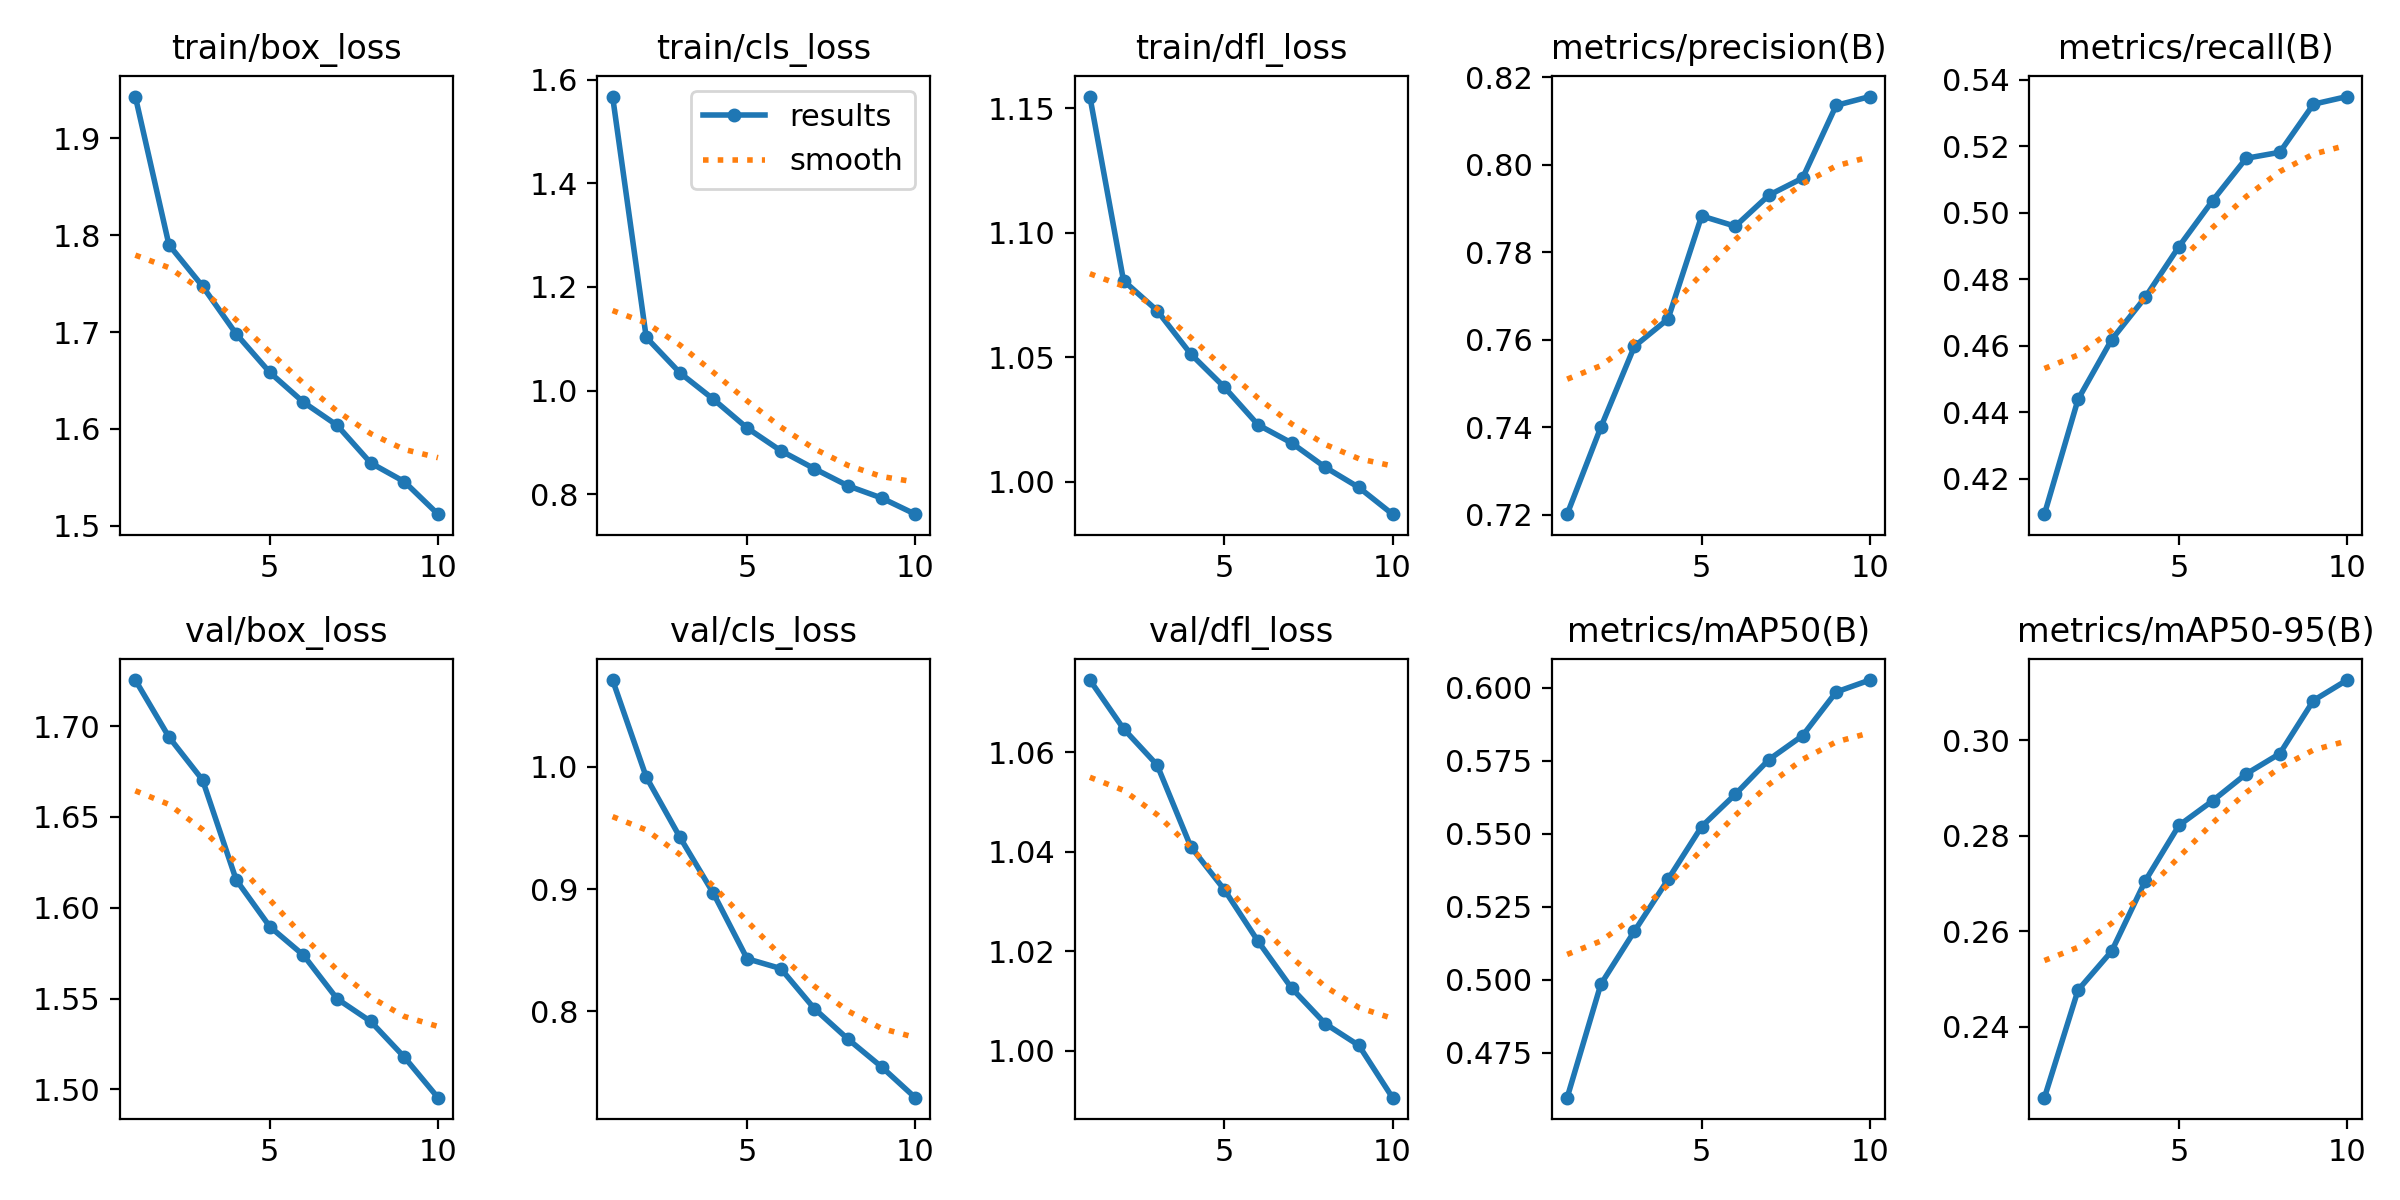


 3 output samples


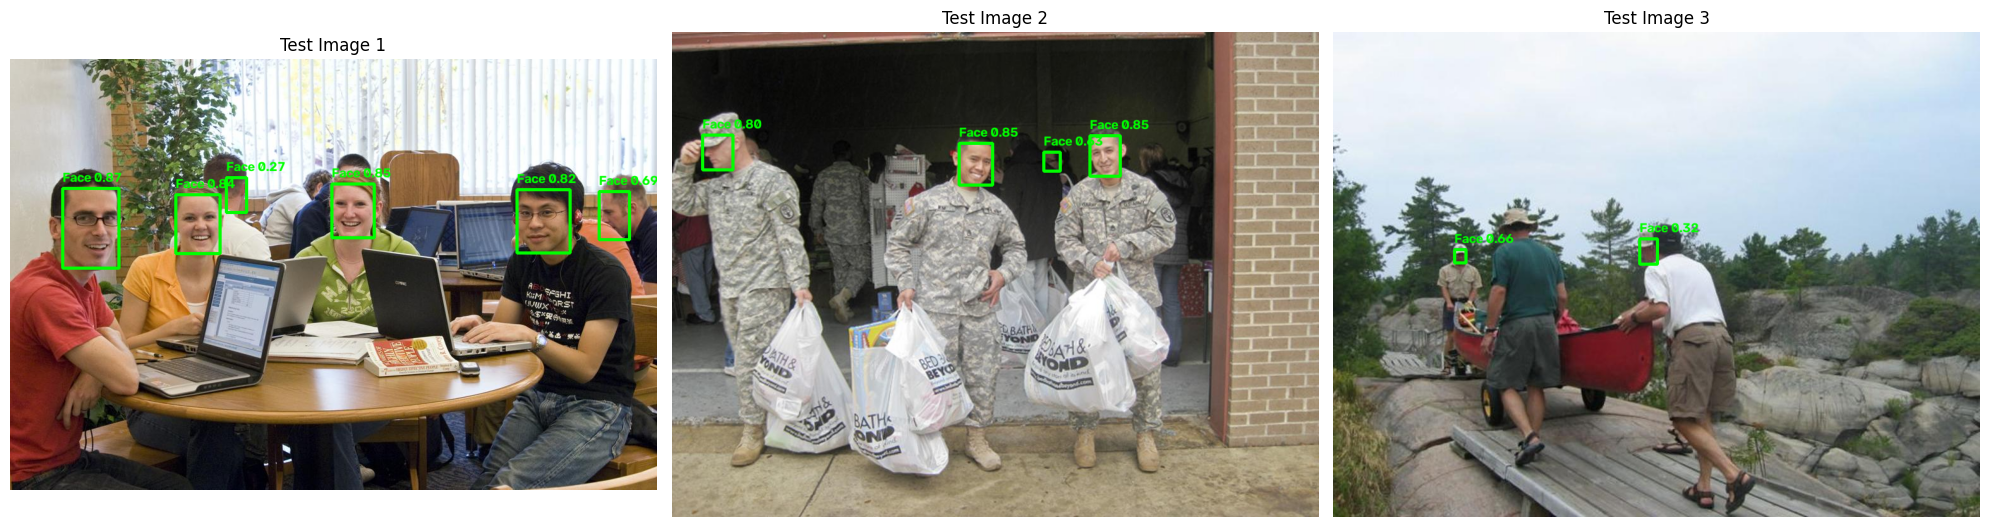

In [18]:
import glob
import random
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display
import os

project_path = '/content/runs/detect/wider_face_project/face_model-2'

print("Loss, mAP:")
results_plot = os.path.join(project_path, 'results.png')
if os.path.exists(results_plot):
    display(Image(filename=results_plot, width=900))

print("\n 3 output samples")

best_model_path = os.path.join(project_path, 'weights/best.pt')
model = YOLO(best_model_path)
val_images = glob.glob('/content/WIDER_val/images/**/*.jpg', recursive=True)

sample_images = random.sample(val_images, 3)

plt.figure(figsize=(20, 8))

for i, img_path in enumerate(sample_images):
    results = model.predict(img_path, conf=0.25, verbose=False)

    img = cv2.imread(img_path)

    for r in results:
        if r.boxes is not None:
            for box in r.boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])

                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
                cv2.putText(img, f'Face {conf:.2f}', (x1, max(y1 - 10, 10)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 3, i + 1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Test Image {i+1}')

plt.tight_layout()
plt.show()